# Data Science in Psychology and Neuroscience

## Class info:
* Week #7
* Day: March 5, 2026
* Time: 9:30—10:45 AM
* Location: Logan Hall 125
* <a href="https://forms.microsoft.com/r/26vAcJWrwH">Click here to submit your attendance for Week 7, Question 14!</a>
  
## Instructor info:
* Dr. Jeremy Hogeveen
* jhogeveen@unm.edu
* Logan Hall 281 (Office Hours By Appointment)
  
## Syllabus:
* <a href="https://www.dropbox.com/scl/fi/6fs6fi4kvkwtxn7j7x8ua/PSY450650_DSPN_Spring2026_Syllabus.pdf?rlkey=148e5t4ah8q2n1daclt7mp0h6&dl=0">Download here</a>

## Today's topic:
1. intro with simple data
    * ggplot basics
2. adding complexity
    * layering plots
    * misc formatting stuff
3. Homework
    * If you haven't, start brainstorming final assignment ideas!

# Section 1: Forming a simple dataset to plot

## 1.1 Backround

* Data are from classic paper in psychology, "The Formation of Learning Sets" (<a href="https://psycnet.apa.org/record/1949-03097-001">Harlow, 1949</a>)

* Animals performed a 2 alternative forced choice task, where one item was rewarded while the other was not.

<img src="img/learning_sets_task.png" width=300>

* Plotted learning curves after repeated exposures to the same stimuli.

<img src="img/learning_sets_data.png" width=300>

## 1.2 Make a plot of first block learning across time 

* Let's generate a rough match to the "preliminary discriminations" data in `ggplot2`.

In [2]:
# load package
suppressPackageStartupMessages(library(tidyverse))

In [3]:
# generating summary data to show early, middly, late learning phases
list_trial <- c(1, 2, 3, 4, 5, 6)
list_first_block <- c(50,51.7,58.8,68.8,71.9,77.9)
list_middle_block <- c(50,78.8,83,84.2,90.1,92.7)
list_last_block <- c(50,96.9,97.8,98.1,98.8,98.7)
df_learning <- tibble(trial = list_trial,
                         first_block = list_first_block,
                         middle_block = list_middle_block,
                         last_block = list_last_block)
# df_learning.head()
head(df_learning)

trial,first_block,middle_block,last_block
<dbl>,<dbl>,<dbl>,<dbl>
1,50.0,50.0,50.0
2,51.7,78.8,96.9
3,58.8,83.0,97.8
4,68.8,84.2,98.1
5,71.9,90.1,98.8
6,77.9,92.7,98.7


### Basic `ggplot` syntax

`ggplot(data = <DATA>) +`
`<GEOM_FUNCTION>(aes(<MAPPINGS>))`

or 

`ggplot(data = <DATA>, aes(<MAPPINGS>)) +`
`<GEOM_FUNCTION>)`

* ggplot initiates a blank plot object
* aes = aesthetic mappings
    * Can occur at the ggplot or the geom level, as needed
* geom_functions = geometric objects (<a href="https://ggplot2.tidyverse.org/reference/index.html">list of options</a>)

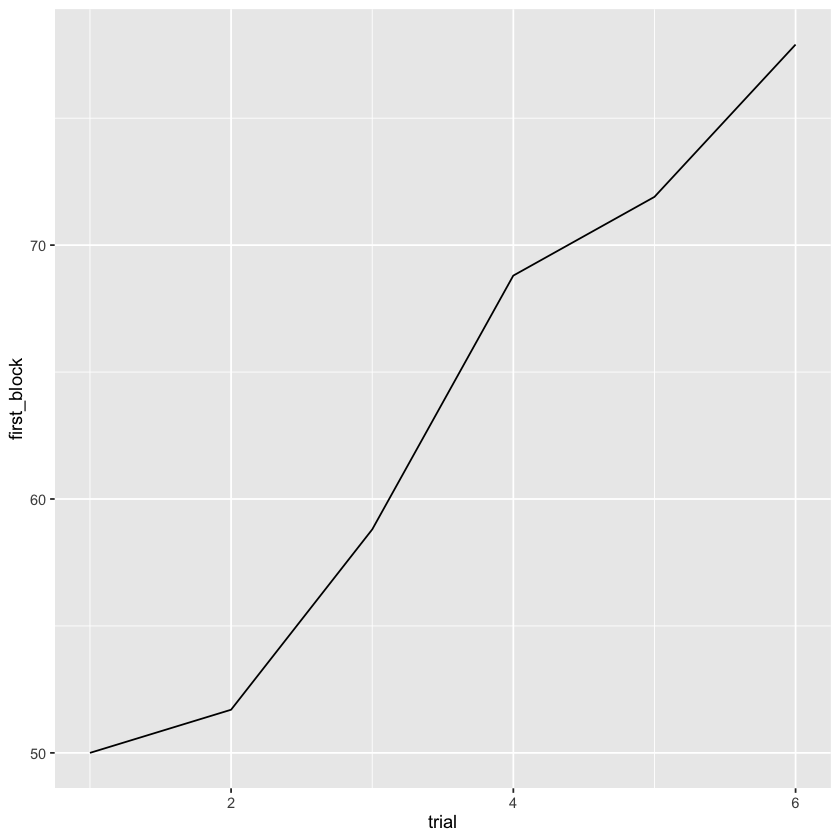

In [6]:
# plot_learning <- ggplot

# plot_learning <- ggplot(df_learning, aes(x = trial, y = first_block))

plot_learning <- ggplot(df_learning, aes(x = trial, y = first_block)) +
    geom_line()

plot_learning

## 1.3 Make a plot with all blocks

* Often, we may want to plot multiple series of y ~ f(x).

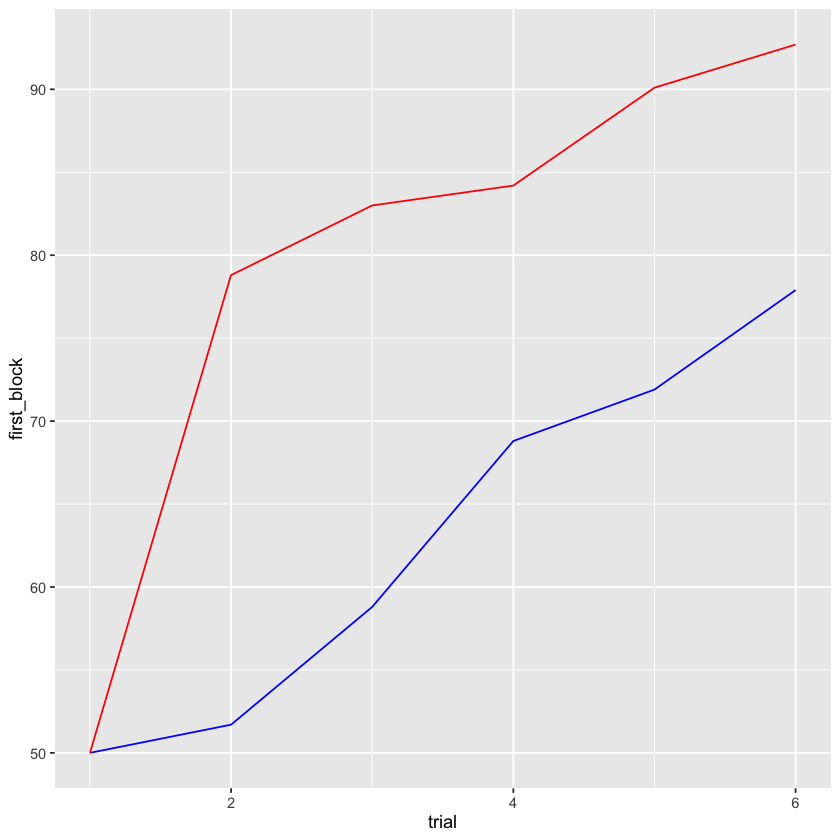

In [7]:
# add middle block geom_line
plot_learning_twoblocks <- ggplot(df_learning, aes(x = trial)) +
    geom_line(aes(y = first_block), colour = "blue") +
    geom_line(aes(y = middle_block), colour = "red")

plot_learning_twoblocks

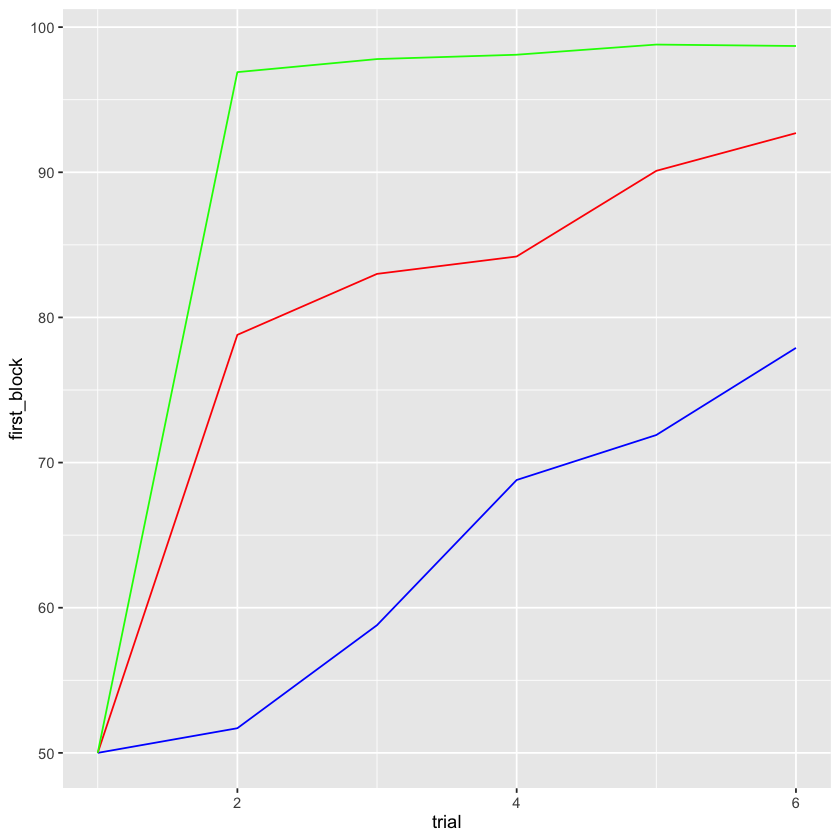

In [9]:
# Add last block
plot_learning_twoblocks + geom_line(aes(y = last_block), colour = "green")

## 1.4 What if we want to add this all in one step?

* Answer: pivot_longer(), then plot again!

In [10]:
df_learning_long <- df_learning %>%
    pivot_longer(cols = ends_with('block'),
                 names_to = 'block',
                 values_to = 'perc_corr')

head(df_learning_long)

trial,block,perc_corr
<dbl>,<chr>,<dbl>
1,first_block,50.0
1,middle_block,50.0
1,last_block,50.0
2,first_block,51.7
2,middle_block,78.8
2,last_block,96.9


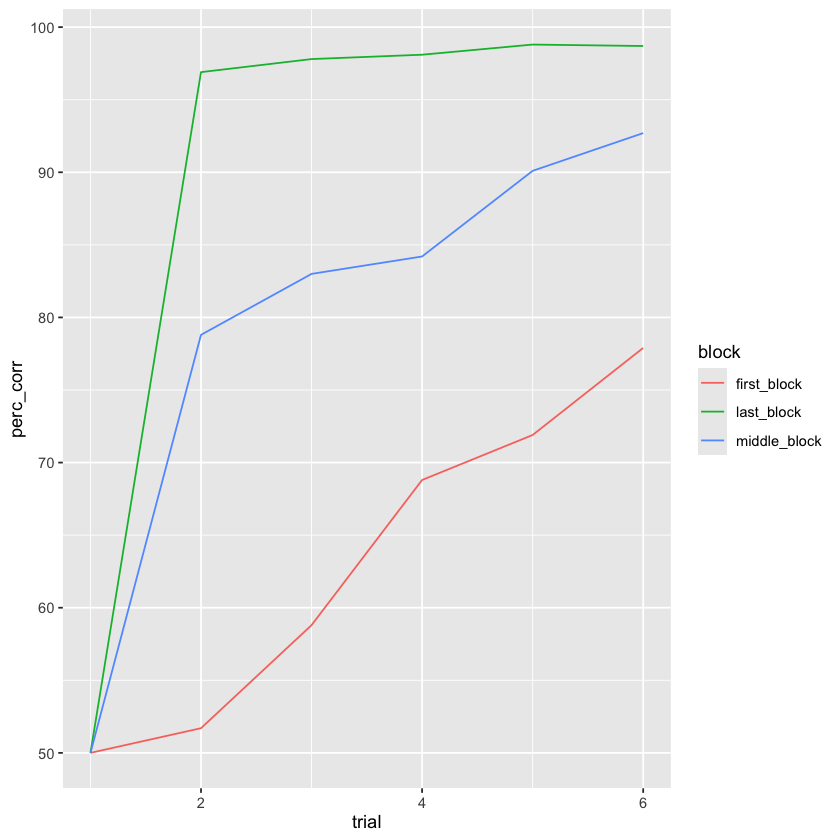

In [11]:
plot_learning_long <- ggplot(df_learning_long,aes(x = trial, y = perc_corr, colour = block)) +
    geom_line()
plot_learning_long

# Section 2. Adding complexity to our basic ggplot infrastructure

## 2.1 Reading in some of the ABCD study data.

<img src="img/abcdlogo500.jpg" width=300>

* Test: Does NAcc activity during reward anticipation vary across ABCD study sites?
    * <a href="https://www.jneurosci.org/content/jneuro/21/16/RC159.full.pdf">Monetary incentive delay (MID) task </a>
    * Relevant papers: <a href="https://www.sciencedirect.com/science/article/pii/S1053811921008909">Multi‐band FMRI compromises detection of mesolimbic reward responses</a>

<img src="img/mid_task.png" width=400>

<img src="img/mid_fmri.png" width=200>

### Let's load in the relevant ABCD data and wrangle it in R

In [14]:
# simplifying to use absolute path to base dir in R
base_dir <- "/Users/jeremyhogeveen/Dropbox/Winter_2026/teaching/DSPN_Spring_2026/github"
data_dir <- file.path(base_dir,"data/abcd_synthetic")

# filepaths
file_subjects <- file.path(data_dir,"subjectkeys.txt")
file_site <- file.path(data_dir,"abcd_lt01.txt")
file_demo <- file.path(data_dir,"pdem02.txt")
file_midfmri <- file.path(data_dir,"midaparc03_redo.txt")

* note: making a quick function to make reading ABCD data easier in R (skipping second descriptive row...)

In [15]:
# skip row2 function
read_tsv_skip_row2 <- function(file_path, subjectkeys_path) {
  # Read the list of valid subject keys from the text file
  valid_keys <- readLines(subjectkeys_path, warn = FALSE)
  # Getting list of column names to apply after reading in data only
  col_names <- colnames(read_tsv(file_path, n_max = 0, show_col_types = FALSE))
  # Reading in data skipping first two rows
  df <- read_tsv(file_path, skip = 2, col_names = FALSE, show_col_types = FALSE)
  # Adding column names back to the data frame
  colnames(df) <- col_names
  # Filtering the dataframe to only include valid subjectkeys
  df <- df %>%
    filter(subjectkey %in% valid_keys)
  # Returning the df for use after the f(x) is done
  return(df)
}

In [18]:
# Using the function to read in df's
df_site <- read_tsv_skip_row2(file_site,file_subjects)
df_demo <- read_tsv_skip_row2(file_demo,file_subjects)
df_midfmri <- read_tsv_skip_row2(file_midfmri,file_subjects)

head(df_demo)
# str(df_demo)

eventname,subjectkey,sex,demo_gender_id_v2,interview_age,demo_comb_income_v2,demo_fam_exp1_v2,demo_prnt_marital_v2,demo_prnt_ethn_v2,demo_prnt_race_a_v2___10,⋯,demo_prnt_race_a_v2___15,demo_prnt_race_a_v2___16,demo_prnt_race_a_v2___17,demo_prnt_race_a_v2___18,demo_prnt_race_a_v2___19,demo_prnt_race_a_v2___20,demo_prnt_race_a_v2___21,demo_prnt_race_a_v2___22,demo_prnt_race_a_v2___23,demo_prnt_race_a_v2___24
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
baseline_year_1_arm_1,NDAR_INV000060,1,1,117,2,1,0,1,1,⋯,1,0,0,1,1,0,0,2,0,2
baseline_year_1_arm_1,NDAR_INV000062,2,0,111,1,0,2,1,777,⋯,777,0,1,0,777,0,1,2,1,777
baseline_year_1_arm_1,NDAR_INV000074,2,0,111,2,0,777,2,0,⋯,0,0,2,0,0,0,1,2,777,777
baseline_year_1_arm_1,NDAR_INV000075,2,2,115,777,0,1,1,2,⋯,0,1,2,777,2,777,1,1,1,2
baseline_year_1_arm_1,NDAR_INV000079,777,777,112,0,1,777,1,2,⋯,2,1,2,1,777,1,0,2,1,2
baseline_year_1_arm_1,NDAR_INV000083,1,777,115,777,1,2,0,2,⋯,1,0,1,0,2,0,777,777,2,1


In [19]:
# merging data based on subjectkley and eventname
list_of_dfs <- list(df_site, df_demo, df_midfmri)
df_all <- reduce(list_of_dfs, full_join, by=c('subjectkey','eventname'))

In [20]:
head(df_all)

eventname,subjectkey,site_id_l,sex,demo_gender_id_v2,interview_age,demo_comb_income_v2,demo_fam_exp1_v2,demo_prnt_marital_v2,demo_prnt_ethn_v2,⋯,mid_ant_rew_v_neut_l_amygdala,mid_ant_rew_v_neut_r_amygdala,mid_ant_rew_v_neut_dacc,mid_ant_loss_v_neut_l_nacc,mid_ant_loss_v_neut_r_nacc,mid_ant_loss_v_neut_vmpfc,mid_ant_loss_v_neut_anterior_insula,mid_ant_loss_v_neut_l_amygdala,mid_ant_loss_v_neut_r_amygdala,mid_ant_loss_v_neut_dacc
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
baseline_year_1_arm_1,NDAR_INV000060,site02,1,1,117,2,1,0,1,⋯,0.4423,-0.1168,0.1092,1.0451,0.2462,0.1861,1.1019,-0.1318,-0.4267,1.7705
baseline_year_1_arm_1,NDAR_INV000062,site01,2,0,111,1,0,2,1,⋯,0.3236,1.4741,1.8641,0.8714,0.5109,-0.0158,1.1031,0.7952,-0.0770,0.7190
baseline_year_1_arm_1,NDAR_INV000074,site01,2,0,111,2,0,777,2,⋯,0.1316,1.2235,1.0082,-0.9102,0.0398,-0.1462,1.7546,-0.5126,0.7614,0.2414
baseline_year_1_arm_1,NDAR_INV000075,site01,2,2,115,777,0,1,1,⋯,0.3854,0.7150,1.4728,1.2314,-0.9973,0.4331,0.7093,0.9416,0.6188,1.2577
baseline_year_1_arm_1,NDAR_INV000079,site03,777,777,112,0,1,777,1,⋯,0.0584,-0.0613,1.8865,0.3505,1.9189,0.5198,1.3349,0.1369,-0.0409,0.4151
baseline_year_1_arm_1,NDAR_INV000083,site01,1,777,115,777,1,2,0,⋯,-0.1147,-0.1318,1.2645,0.2003,0.1882,0.9030,0.7553,0.6286,1.5237,-0.5958


## 2.2 Wrangling just the data we need for this test

* Filter to baseline visit

In [22]:
# `filter` rows
df_baseline <- df_all %>%
    filter(eventname == "baseline_year_1_arm_1",
          mid_ant_rew_v_neut_l_nacc != "NA")

* Select the following columns:
    * `subjectkey`
    * `site_id_l`
    * `mid_ant_rew_v_neut_l_nacc`
    * `mid_ant_rew_v_neut_r_nacc`

In [24]:
# `select` columns
df_baseline_filt <- df_baseline %>%
    select(subjectkey,
           site_id_l,
           mid_ant_rew_v_neut_l_nacc,
           mid_ant_rew_v_neut_r_nacc)

# `mutate` to get bilateral NACC
df_baseline_filt <- df_baseline_filt %>%
    mutate(mid_ant_rew_v_neut_bi_nacc = (mid_ant_rew_v_neut_l_nacc + mid_ant_rew_v_neut_r_nacc) / 2) 
head(df_baseline_filt)

subjectkey,site_id_l,mid_ant_rew_v_neut_l_nacc,mid_ant_rew_v_neut_r_nacc,mid_ant_rew_v_neut_bi_nacc
<chr>,<chr>,<dbl>,<dbl>,<dbl>
NDAR_INV000060,site02,1.9597,-0.0222,0.96875
NDAR_INV000062,site01,1.7882,1.6715,1.72985
NDAR_INV000074,site01,1.2746,1.4217,1.34815
NDAR_INV000075,site01,1.4618,1.9387,1.70025
NDAR_INV000079,site03,1.4862,1.3268,1.40650
NDAR_INV000083,site01,0.7476,1.1795,0.96355


## 2.3 Making a boxplot to compare

* If plotting ROI series (L, R, and bilateral) separately, no need to reshape.

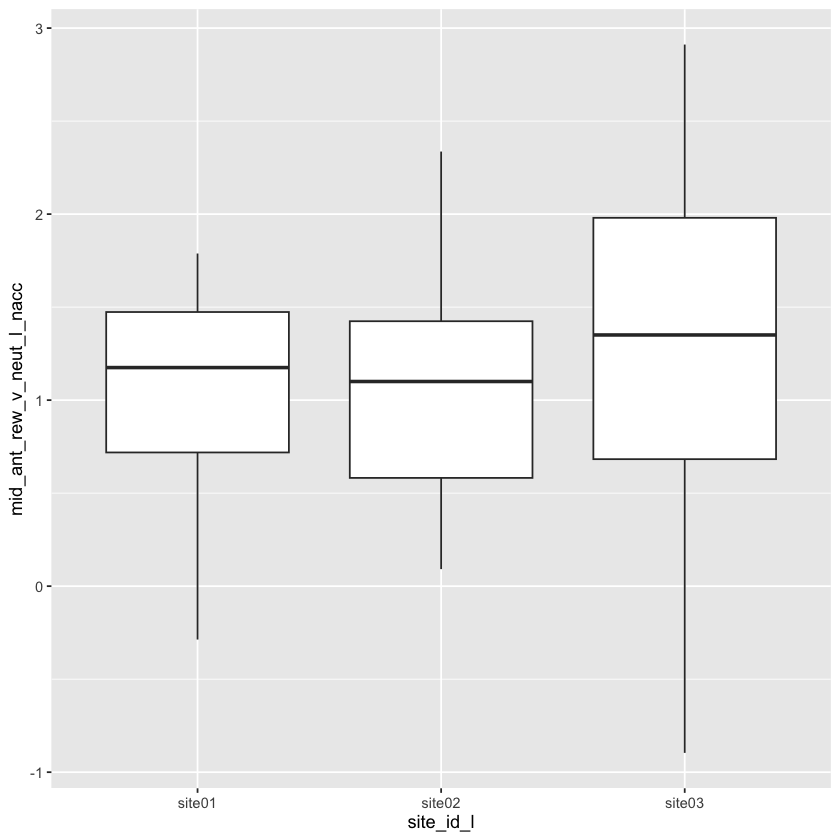

In [25]:
# making a basic box plot
plot_box_L_Nacc <- ggplot(df_baseline_filt,aes(x = site_id_l, y = mid_ant_rew_v_neut_l_nacc)) +
    geom_boxplot()

plot_box_L_Nacc

## 2.4 Adding some layers.

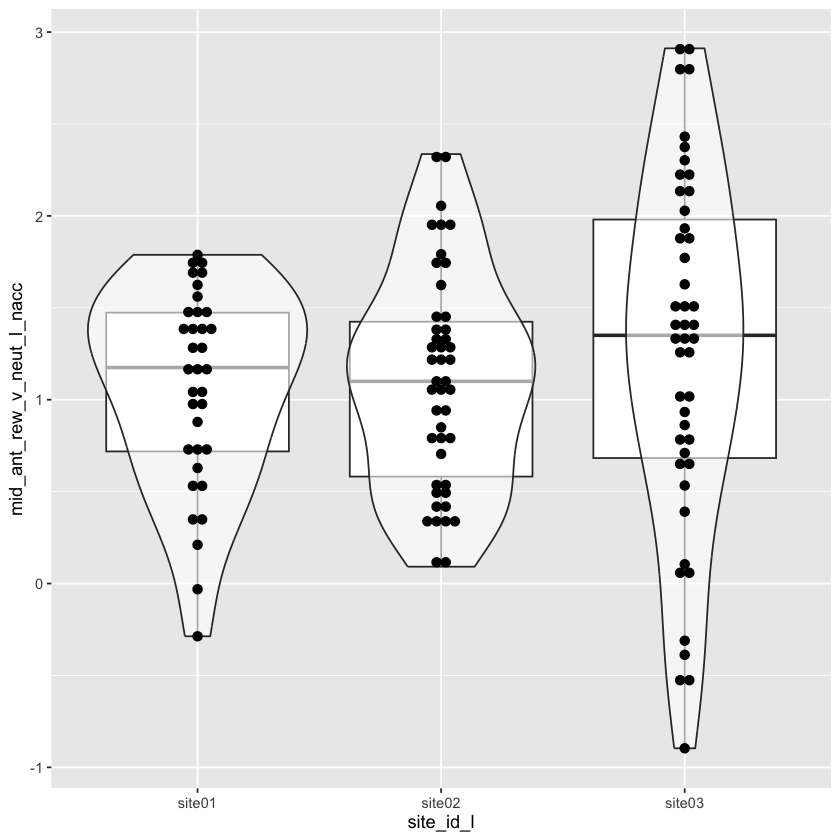

In [34]:
# making a layered plot
plot_layered_box_L_Nacc <- ggplot(df_baseline_filt,aes(x = site_id_l, y = mid_ant_rew_v_neut_l_nacc)) +
    geom_boxplot() +
    geom_violin(alpha=0.6) +
    geom_dotplot(binaxis='y',binwidth = .05, stackdir = 'center')

plot_layered_box_L_Nacc

## 2.4 Grouping by hemisphere

* First we'll want to lengthen the data

In [42]:
# pivot longer
df_baseline_filt_long <- df_baseline_filt %>%
    pivot_longer(cols = contains('nacc'),
                 names_to = 'hemisphere',
                 values_to = 'bold')

df_baseline_filt_long <- df_baseline_filt_long %>% 
    mutate(shorthem = ifelse(grepl("_l_",hemisphere),"left",
                             ifelse(grepl("_r_",hemisphere),"right",
                                    ifelse(grepl("_bi_",hemisphere),"bilateral",""))))
                                   

head(df_baseline_filt_long)

subjectkey,site_id_l,hemisphere,bold,shorthem
<chr>,<chr>,<chr>,<dbl>,<chr>
NDAR_INV000060,site02,mid_ant_rew_v_neut_l_nacc,1.95970,left
NDAR_INV000060,site02,mid_ant_rew_v_neut_r_nacc,-0.02220,right
NDAR_INV000060,site02,mid_ant_rew_v_neut_bi_nacc,0.96875,bilateral
NDAR_INV000062,site01,mid_ant_rew_v_neut_l_nacc,1.78820,left
NDAR_INV000062,site01,mid_ant_rew_v_neut_r_nacc,1.67150,right
NDAR_INV000062,site01,mid_ant_rew_v_neut_bi_nacc,1.72985,bilateral


* First, grouping the hemisphere data with `colour`

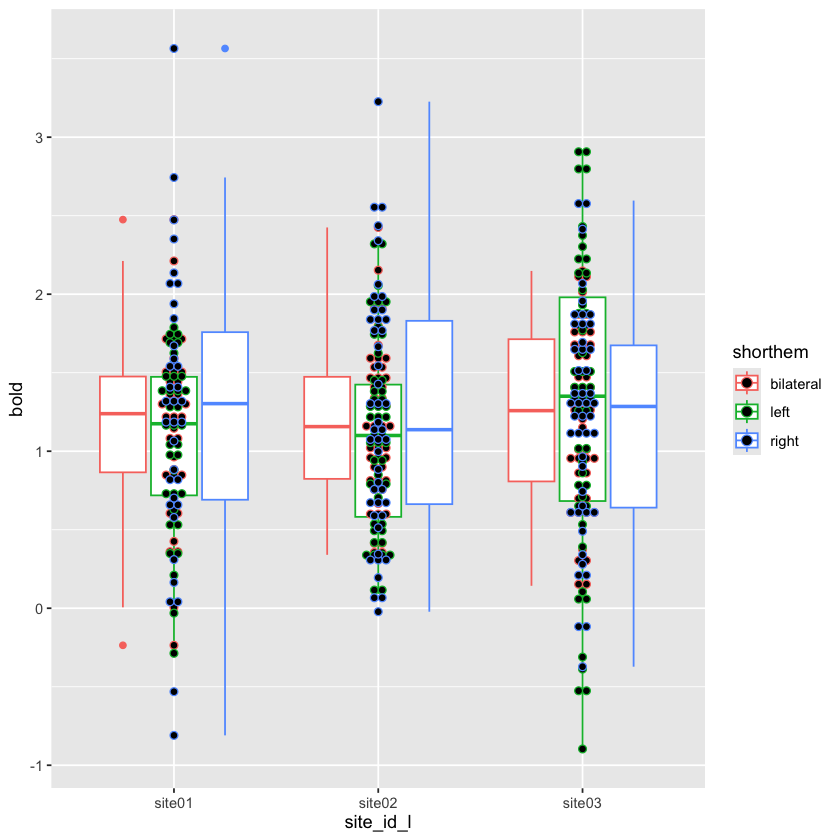

In [43]:
plot_byhemisphere <- ggplot(df_baseline_filt_long,aes(x = site_id_l, y = bold, colour = shorthem)) +
    geom_boxplot() +
    geom_dotplot(binaxis='y',binwidth = .05, stackdir = 'center')

plot_byhemisphere

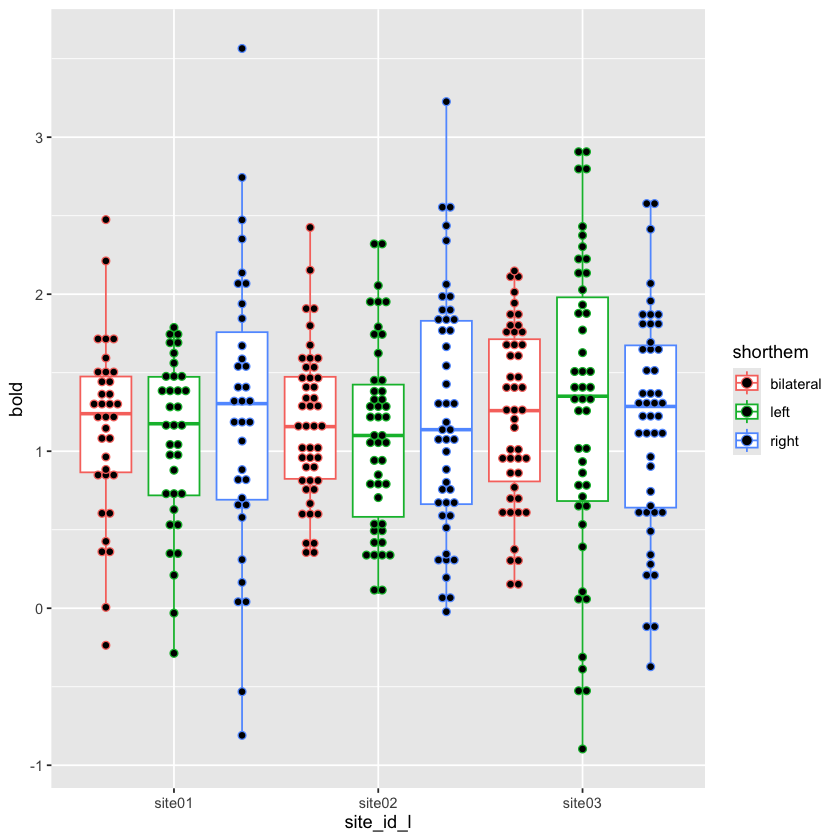

In [48]:
# fixing the position for the plots using position_dodge
dodge <- position_dodge(1)

# adding in dodge
plot_byhemisphere_wdodge <- ggplot(df_baseline_filt_long,aes(x = site_id_l, y = bold, colour = shorthem)) +
    geom_boxplot(position = dodge) +
    geom_dotplot(position = dodge,binaxis='y',binwidth = .05, stackdir = 'center')

plot_byhemisphere_wdodge

* Grouping with `fill` instead of `colour`

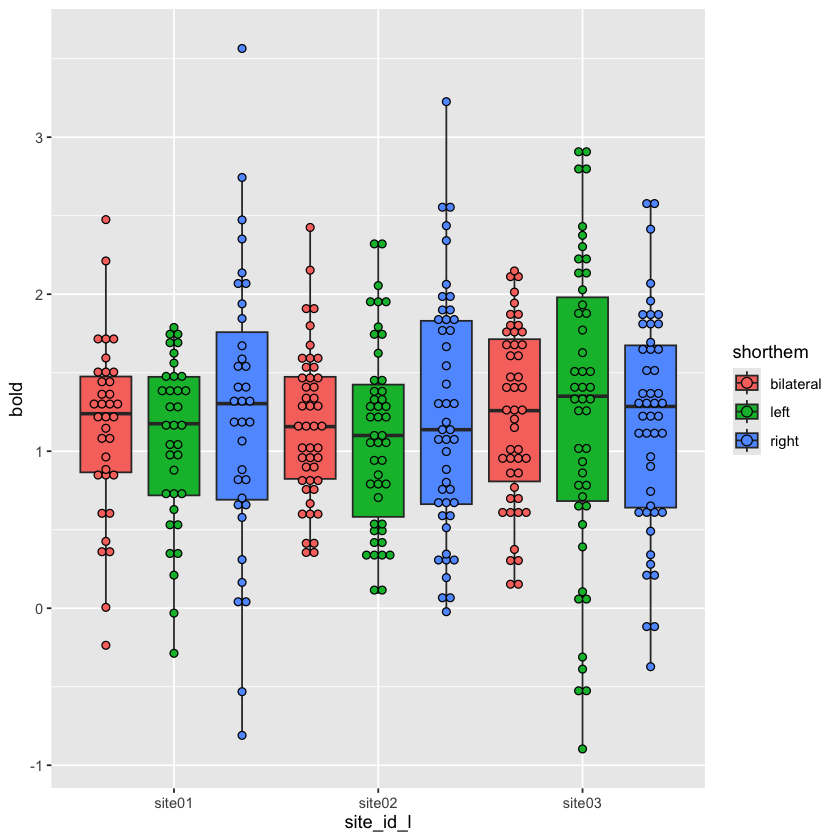

In [49]:
# grouping with fill instead of colour
plot_byhemisphere_wfill_wdodge <- ggplot(df_baseline_filt_long,aes(x = site_id_l, y = bold, fill = shorthem)) +
    geom_boxplot(position = dodge) +
    geom_dotplot(position = dodge,binaxis='y',binwidth = .05, stackdir = 'center')

plot_byhemisphere_wfill_wdodge

## 2.6 Formatting the plots (Themes)
* Plot outline / background
* Axis labels

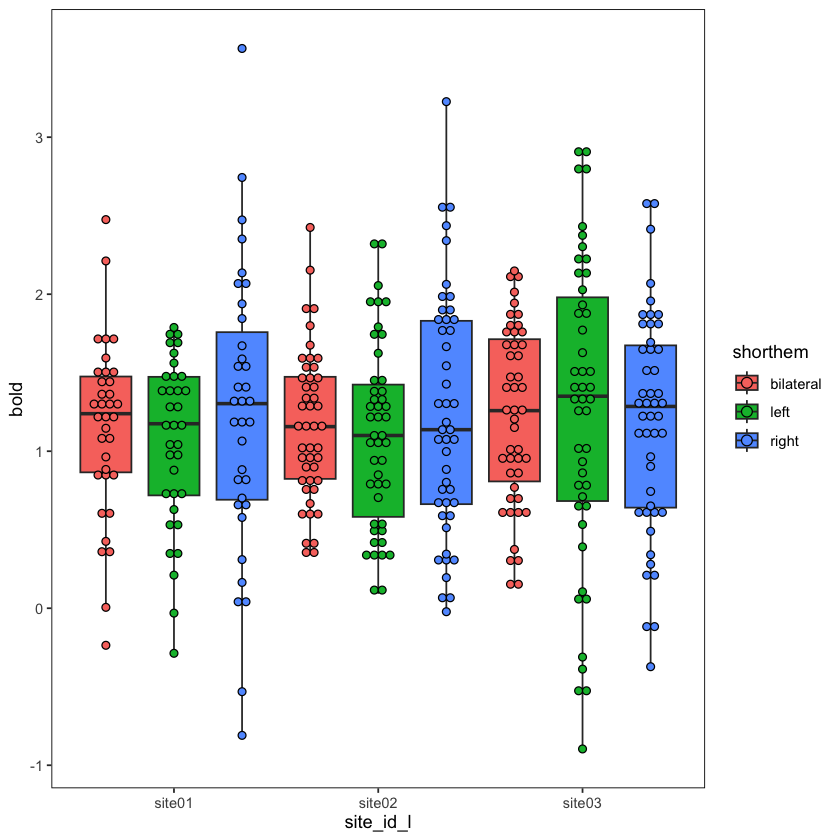

In [50]:
plot_byhemisphere_wfill_wdodge +
    theme(panel.background = element_rect(fill="#ffffff",colour=NA),
          panel.border = element_rect(fill = NA, color = "black"))

In [51]:
# some stuff you can steal for customizing data visualizations:

# Many palettes available online, can customize
# these are from: https://colorbrewer2.org/#type=qualitative&scheme=Set1&n=9
my_palette <- c("#0000FF","#FF0000","#3ADF00","#ff7f00","#6a3d9a",
                "#a6cee3","#b2df8a","#fb9a99","#fdbf6f","#cab2d6",
                "#8dd3c7","#bebada","#d9d9d9","#fccde5","#ffffb3")

# This is the basic function I use for all the ggplots I create. 
# Modified from this black themed ggplot function: https://gist.github.com/jslefche/eff85ef06b4705e6efbc
my_theme = function(base_size = 24, base_family = "") {
  
  theme_grey(base_size = base_size, base_family = base_family) %+replace%
    
    theme(
      # Specify axis options
      axis.line = element_blank(),  
      axis.text.x = element_text(size = base_size*0.8, color = "black", lineheight = 0.9),  
      axis.text.y = element_text(size = base_size*0.8, color = "black", lineheight = 0.9),  
      axis.ticks = element_line(color = "black", size  =  0.2),
      axis.title.x = element_text(size = base_size, color = "black", margin = margin(10, 0, 0, 0)),
      axis.title.y = element_text(size = base_size, color = "black", angle = 90, margin = margin(0, 10, 0, 0)),  
      axis.ticks.length = unit(0.3, "lines"),   
      # Specify legend options
      legend.background = element_rect(color = NA, fill = "#ffffff"),  
      legend.key = element_rect(color = "black",  fill = "#ffffff"),  
      legend.key.size = unit(2, "lines"),  
      legend.key.height = NULL,  
      legend.key.width = NULL,      
      legend.text = element_text(size = base_size*0.8, color = "black"),  
      legend.title = element_text(size = base_size*0.8, face = "bold", hjust = 0, color = "black"),
      legend.position = "right",  
      legend.text.align = NULL,  
      legend.title.align = NULL,  
      legend.direction = "vertical",  
      legend.box = NULL, 
      # Specify panel options
      panel.background = element_rect(fill = "#ffffff", color  =  NA),  
      panel.border = element_rect(fill = NA, color = "black"),  
      panel.grid.major = element_line(color = "#ffffff"),  
      panel.grid.minor = element_line(color = "#ffffff"),  
      panel.spacing = unit(2, "lines"),
      # Specify facetting options
      strip.background = element_rect(fill = "grey30", color = "grey10"),  
      strip.text.x = element_text(size = base_size*0.8, color = "black"),  
      strip.text.y = element_text(size = base_size*0.8, color = "black",angle = -90),  
      # Specify plot options
      plot.background = element_rect(color = "#ffffff", fill = "#ffffff"),  
      plot.title = element_text(size = base_size*1.2, color = "black"),  
      plot.margin = unit(rep(1, 4), "lines")
    ) 
}

Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


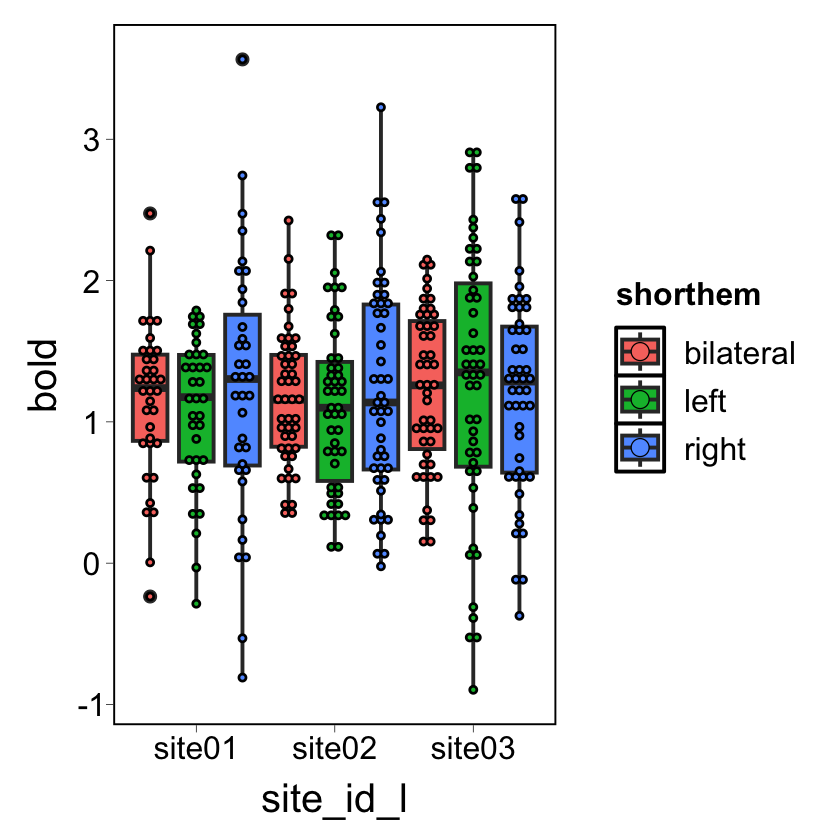

In [52]:
plot_byhemisphere_wfill_wdodge + 
    my_theme()

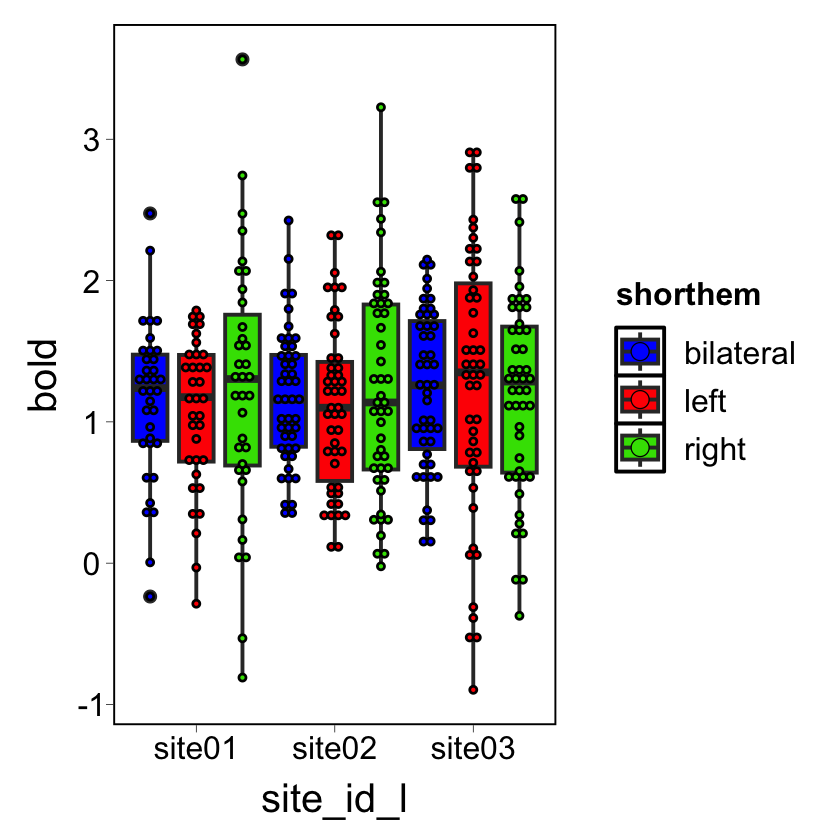

In [55]:
plot_byhemisphere_wfill_wdodge + 
    my_theme() +
    # scale_fill_manual(values=my_palette) 
    scale_fill_manual(values=c(my_palette[1],my_palette[2],my_palette[3]))